In [1]:
# import torch
import numpy as np
import scipy.linalg as la
from ncon import ncon

In [2]:
Dl = 15 # MPS bond dimension
Dr = 17
d = 4 # Physical dimension
chi = 4 # MPO bond dimension

def build_objects(d, Dl, Dr, chi, seed=42):
    np.random.seed(seed)

    L = np.random.normal(0, 1, size=(Dl, Dl, chi)) 
    L = (L + ncon(L.conj(), (-2, -1, -3)))/2 # Both L and R should have a conjugate-swap symmetry
    R = np.random.normal(0, 1, size=(Dr, Dr, chi)) 
    R = (R + ncon(R.conj(), (-2, -1, -3)))/2
    W = np.random.normal(0, 1, size=(d, d, chi, chi)) + 1j*np.random.normal(0, 1, size=(d, d, chi, chi))
    W = (W + np.transpose(W.conj(), [1,0,2,3])) / 2 # Make Hermitian

    C = np.random.normal(size=(d, Dl, Dr))
    C = C/la.norm(C)

    return C, W, L, R

def build_H_eff(W, L, R):
    d, _, _, _ = W.shape
    Dl, _, _ = L.shape
    Dr, _, _ = R.shape
    H_eff = ncon((W, L, R), 
                 ((-1, -4, 1, 2), (-2, -5, 1), (-3, -6, 2))) # Effective centre site hamiltonian
    H_eff_mat = np.reshape(H_eff, (d*Dl*Dr, d*Dl*Dr))
    return H_eff, H_eff_mat


In [3]:
# Using lanczos
def lanczos(v, H, dt=1, epsilon=1e-4, iter_limit=8):
    """
    Lanczos method for computing matrix exponential
    """
    dim = np.shape(v)[0]
    # build the lanczos vectors
    v0 = v / la.norm(v)
    
    vm = [v0]
    converged = False
    iter_limit = 0
    while not converged and iter_limit > len(vm):
        print('loopin')
        v = vm[-1]
        w = H @ v
        for v_i in vm:
            # subtract the projection of w onto each previous vector
            w -= np.dot(v_i.conjugate(), w) * v_i 
        norm_w = la.norm(w)
        if norm_w < epsilon:
            print(f'Norm w/epsilon: {norm_w/epsilon} ')
            converged = True
            break
        vm.append(w / norm_w)
        iter_limit += 1

    Vm = np.column_stack(vm)
    # if not Vm.shape == H_eff_mat.shape:
    #     print(f'Lanczos method saved time! Required {Vm.shape[1]} vectors')
    H_eff = Vm.conj().T @ H @ Vm
    print(f"Dimension of H representation in Lanczos space: {np.shape(H_eff)}")
    # compute the exponential exactly
    mat_exp = la.expm(-0.5*1j*dt*H_eff)
    updated_tensor = (mat_exp @ Vm.T)[:, 0]
    return updated_tensor

In [4]:
e=1e-8
iter_max=100
lanczos(v, H, dt, epsilon=e, iter_limit=iter_max)

NameError: name 'v' is not defined

In [33]:
def apply_Heff_parts(C, W, L, R,):
    con1 = ncon((C, L),
                ((-1, 1,-3), (1, -2, -4)))
    con2 = ncon((con1, W), 
                ((1, -2, -3, 4), (1, -1, 4, -4))) # Could be faster if these legs are vectorised, but isn't bond-dim-critical.
    d1, d2, d3, d4 = con2.shape # d1=d, d2=Dl, d3=Dr, d4=chi

    con2_vec = con2.reshape((d1, d2, d3*d4))
    R_vec = np.transpose(R, [1, 0, 2]).reshape((d3, d3*d4)) #group chi leg and leg connecting to C as last two axes
    con3 = con2_vec @ (R_vec.T) # this has been vectorised for optimal bond dim scaling - this step has D^3 d chi scaling

    return con3

def contract_C(C1, C2):
    """
    Contract two centre gauge tensors <C1, C2>
    Parameters:
        C1, C2 : array of identical shape
            Tensors to contract, both given in ket form (C1 will be conjugated)
    """
    C1_vec = C1.flatten()
    C2_vec = C2.flatten()
    return C1_vec.conj() @ C2_vec

def check_apply_Heff_parts(C, W, L, R):
    con3 = apply_Heff_parts(C, W, L, R)
    con3_check=ncon((C, W, L, R),
                    ((1, 2, 3), (1, -1, 4, 5), (2, -2, 4), (3, -3, 5)))
    assert np.all(np.isclose(con3, con3_check)), (
        print('Contraction order issue')
        )
    
def lanczos_loop(basis, W, L, R):
    C_last = basis[-1]
    HC = apply_Heff_parts(C_last, W, L, R)
    H_cons = [contract_C(C_k, HC) for C_k in basis]
    C_next = HC - sum([H_cons[i]*basis[i] for i in range(len(basis))])
    norm = np.sqrt(contract_C(C_next, C_next))
    return C_next/norm, norm, H_cons

def H_subspace_matrix(H_cons):
    """
    Build the matrix <Ci, H_eff C_j>
    leveraging the fact that it should be hermitian
    """
    n = len(H_cons)
    H_mat = np.zeros((n,n), dtype=type(1+1j))
    for i, col in enumerate(H_cons):
        H_mat[:i+1, i] = col # These are the upper right triangular entries
    H_mat += np.triu(H_mat, 1).conj().T # Copy values to below diagonal.
    return H_mat


def lanczos_parts(C, W, L, R,
                  epsilon=1e-6,
                  max_iters=100):
    """
    Builds the orthogonal basis for the Krylov subspace, 
    and the representation of the Hamiltonian in this basis.
    """
    W=W
    C_normed = C / la.norm(C)
    basis = [C_normed]
    H_cons = []
    for i in range(max_iters):
        # print('iter ', i)
        C_next, norm, H_cons_i = lanczos_loop(basis, W, L, R)
        H_cons.append(H_cons_i)
        if norm < epsilon:
            print("Norm converged; terminating loop")
            print("Norm / epsilon: ", round(np.real(norm/epsilon), 4))
            return basis, H_subspace_matrix(H_cons)
        basis.append(C_next)
    print("Hit iteration limit before convergence")
    print("Norm / epsilon: ", round(np.real(norm/epsilon), 4))
    return basis, H_subspace_matrix(H_cons)

def lanczos_exp(C, W, L, R,
                dt=1,
                epsilon=1e-5,
                max_iters=None):
    if not max_iters:
        max_iters = np.prod(np.shape(C))
        print(f"Iterations unlimited; full space has dimension {np.prod(np.shape(C))}")
    basis, H_mat = lanczos_parts(C, W, L, R, epsilon, max_iters)
    exp_H_mat = la.expm(-1j*dt*H_mat)
    first_col = exp_H_mat[:,0]
    evolved_C = la.norm(C)*sum([C_i*H_i0 for C_i, H_i0 in zip(basis, first_col)]) 
    # We are computing exp(-iHdt).C
    # C = norm(C)* first basis vector
    # the first basis vector picks out the first column of the matrix
    # Could do this with numpy, but shouldnt make a masive difference 
    return evolved_C


In [15]:
def exact_evolve(C, H_eff_mat,
                 dt=1):
    d, Dl, Dr = C.shape
    exact_vec = C.flatten() @ la.expm(-1j*dt*H_eff_mat)
    return exact_vec.reshape((d, Dl, Dr))    

### Comparing output of lanczos vs exact exponential

In [35]:
Dl = 15 # MPS bond dimension
Dr = 17
d = 4 # Physical dimension
chi = 4 # MPO bond dimension

C, W, L, R = build_objects(d, Dl, Dr, chi)

H_eff, H_eff_mat = build_H_eff(W, L, R)

In [36]:
iters = 20
dt=0.01
C_lanc = lanczos_exp(C, W, L, R, dt=dt, max_iters=iters)

Hit iteration limit before convergence
Norm / epsilon:  9085483.0253


In [37]:
# Using linalg
C_exact = exact_evolve(C, H_eff_mat, dt)

In [38]:
# Compare the accuracy
norm_exact = la.norm(C_exact)
norm_lanc = la.norm(C_lanc)
dist = la.norm(C_exact - C_lanc)
print(f"Method exact : norm = {norm_exact} \nMethod Lanczos : norm = {norm_lanc} \nDistance = {dist}")

Method exact : norm = 0.9999999999999998 
Method Lanczos : norm = 0.9999999999999999 
Distance = 1.3102397994388012e-15


Hit iteration limit before convergence
Norm / epsilon:  9744364.5742
Hit iteration limit before convergence
Norm / epsilon:  9544039.5784
Hit iteration limit before convergence
Norm / epsilon:  9464189.3186
Hit iteration limit before convergence
Norm / epsilon:  9134159.837


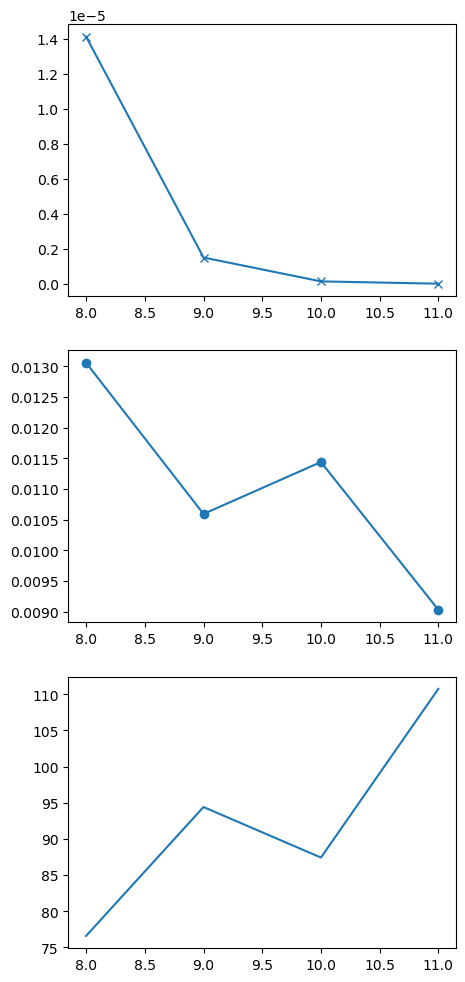

In [43]:
# Error as function of iter limit
import time
iter_lims = [8, 9, 10, 11]
dists = []
times = []
for lim in iter_lims:
    t_i = time.time()
    C_lanc = lanczos_exp(C, W, L, R, dt=dt, max_iters=lim)
    t_f = time.time()
    dists.append(la.norm(C_exact - C_lanc))
    times.append(t_f-t_i)
accuracy_per_second = [(1-dist)/t for dist, t in zip(dists, times)]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,1, figsize=(5, 12))
ax[0].plot(iter_lims, dists, marker='x')
ax[1].plot(iter_lims, times, marker='o')
ax[2].plot(iter_lims, accuracy_per_second)


### Scaling of Lanczos method with fixed iteration limit and increasing bond dimensions

Note that the random matrices will be different at each bond dimension so a direct comparison without sampling is less insightful

In [67]:
iter_lim = 16
d = 4 # Physical dimension
chi = 4 # MPO bond dimension#
dt = 0.01

In [69]:
# Error as function of bond dim
import time
bond_dims = [8,12,16,20,24]
dists = []
times = []
times_ex = []
for dim in bond_dims:
    C, W, L, R = build_objects(d, dim, dim, chi)
    H_eff, H_eff_mat = build_H_eff(W, L, R)
    t_0 = time.time()
    C_lanc = lanczos_exp(C, W, L, R, dt=dt, max_iters=iter_lim)
    t_1 = time.time()
    C_exact = exact_evolve(C, H_eff_mat, dt)
    t_2 = time.time()
    dists.append(la.norm(C_exact - C_lanc))
    times.append(t_1-t_0)
    times_ex.append(t_2-t_1)
time_ratio = [t_ex / t for t,t_ex in zip(times, times_ex)]

Hit iteration limit before convergence
Norm / epsilon:  3919603.8847
Hit iteration limit before convergence
Norm / epsilon:  7862141.5916
Hit iteration limit before convergence
Norm / epsilon:  9102183.5515
Hit iteration limit before convergence
Norm / epsilon:  11879726.8853
Hit iteration limit before convergence
Norm / epsilon:  14007561.5695


Text(0.5, 0, 'Bond dimension')

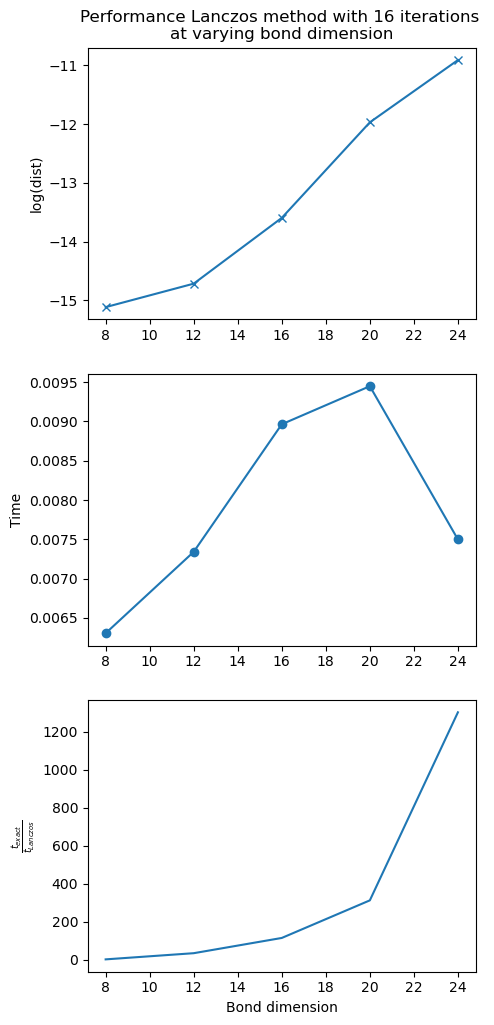

In [70]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,1, figsize=(5, 12))
ax[0].plot(bond_dims, np.log10(dists), marker='x')
ax[0].set_ylabel('log(dist)')
ax[0].set_title(f'Performance Lanczos method with {iter_lim} iterations \nat varying bond dimension')

ax[1].plot(bond_dims, times, marker='o')
ax[1].set_ylabel('Time')

ax[2].plot(bond_dims, time_ratio)
ax[2].set_ylabel(r'$\frac{t_{exact}}{t_{Lanczos}}$')
ax[2].set_xlabel('Bond dimension')

Performance gains really kick in above D=20, near the 1-second barrier for the exact exponential. The time for the Lanczos loop to execute is roughly constant, but it should be growing like D^3 for large bond dimensions. That it isn't suggests the `for` loop is still a large time sink.

The error grows exponentially in bond dimension. $D \approx \times 4 \rightarrow \varepsilon\approx \times 10^7$.

To improve error we must increase iterations. One iteration should improve accuracy by a factor of roughly $\delta t |H|$. To check this, increase iter limit by 1:

In [73]:
# Error as function of bond dim
iter_lim +=1
import time
bond_dims = [8,12,16,20,24]
dists = []
times = []
times_ex = []
for dim in bond_dims:
    C, W, L, R = build_objects(d, dim, dim, chi)
    H_eff, H_eff_mat = build_H_eff(W, L, R)
    t_0 = time.time()
    C_lanc = lanczos_exp(C, W, L, R, dt=dt, max_iters=iter_lim)
    t_1 = time.time()
    C_exact = exact_evolve(C, H_eff_mat, dt)
    t_2 = time.time()
    dists.append(la.norm(C_exact - C_lanc))
    times.append(t_1-t_0)
    times_ex.append(t_2-t_1)
time_ratio = [t_ex / t for t,t_ex in zip(times, times_ex)]

Hit iteration limit before convergence
Norm / epsilon:  4257791.3784
Hit iteration limit before convergence
Norm / epsilon:  7290964.1985
Hit iteration limit before convergence
Norm / epsilon:  9328701.4778
Hit iteration limit before convergence
Norm / epsilon:  11889810.328
Hit iteration limit before convergence
Norm / epsilon:  14873294.3889


Text(0.5, 0, 'Bond dimension')

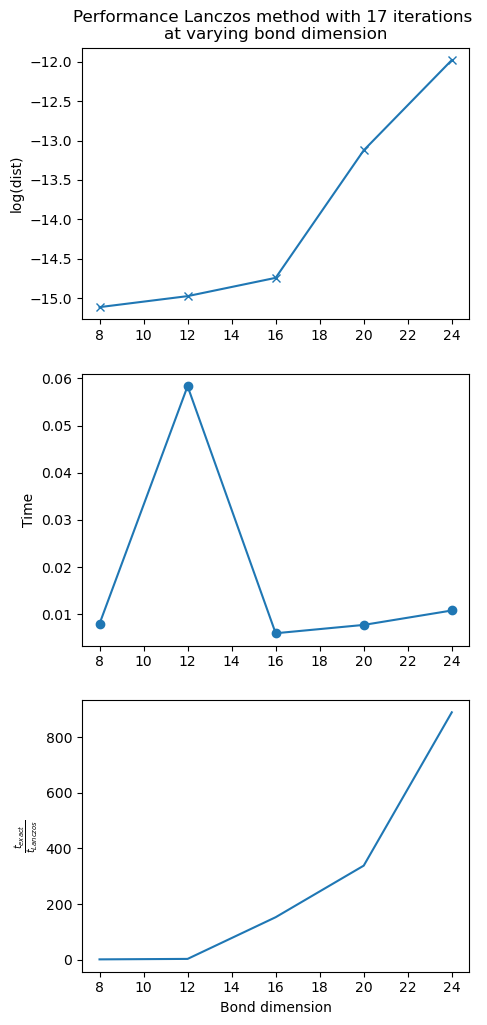

In [72]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,1, figsize=(5, 12))
ax[0].plot(bond_dims, np.log10(dists), marker='x')
ax[0].set_ylabel('log(dist)')
ax[0].set_title(f'Performance Lanczos method with {iter_lim} iterations \nat varying bond dimension')

ax[1].plot(bond_dims, times, marker='o')
ax[1].set_ylabel('Time')

ax[2].plot(bond_dims, time_ratio)
ax[2].set_ylabel(r'$\frac{t_{exact}}{t_{Lanczos}}$')
ax[2].set_xlabel('Bond dimension')